In [1]:
# Euskera v1.0

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
cd ..

/Users/armandoroqueestrada/Library/Mobile Documents/com~apple~CloudDocs/GitHub/Euskera


Euskera v1.

# Simulation of Two Gaussians in a Central Potential

In this notebook, we consider a point-like central potential associated with a mass cmass and two 3D Gaussians located along the $x$-axis.


In [4]:
import multiprocessing
import euskera as eu

import numpy as np
import matplotlib.pyplot as plt

#### Simulation Parameters

In [6]:
tmax = 5  # limit of time take to used on the simulation
save_number = 2 * int(tmax)  # number of the save
resol = 160

name_save = "simulation_data/gaussiana_central_pot"

In [12]:
#### identifying the cpu_processing number
num_threads = multiprocessing.cpu_count()  

#### Symulation Parameters
simulation_parameters = {
"lambda_value": 0,  # Self-interaction coupling constant.
"num_threads": num_threads,  # Set the number of threads to use.
"gridlength": 20,  # Length of the grid in codec units.
"resol": resol, # Grid resolution. The grid is computed using:
              # linspace(-gridlength/2.0 + gridlength/(2.0*resol), 
              #           gridlength/2.0 - gridlength/(2.0*resol), resol).
"step_factor": 1.,  # Increase this if velocities are low enough that the timestep constraint can be relaxed.
"t0": 0,  # Initial time.
"tmax": tmax,  # Total simulation time.
"Plim": 0,  # Boundary radius of the soliton.
"rmax": 0,  # Two rmax define the minimum separation between solitons 
              # to ensure they are not overlapping.
"cmass": 5,  # Central mass, given in the same units as the soliton mass.
"plott0": True,  # Show the initial profile if True.
"Boverlap": False,  # Check for possible overlap if True.
"methodEnerg": 1,  # methodology used to computed the kinetic contribution
"info": False  # Print extra information if True.
}

#### Save data information/parameters
salva_data = {
  "format": "npz",  # Format used to save data. Supported formats: "npz" and "hdf5".
  "address": name_save,  # Directory where the data will be saved.
  "save_number": save_number,  # Number of frames to save within the time interval [t0, tmax].
  "data_save" : {"grid": True,  # Save grid data.
                 "save_rho": True,   # Save density field (ρ) if True.
                 "save_psi": False,  # Save wavefunction (ψ) if True.
                 "save_phi": True,  # Save potential (φ) if True.
                 "save_plane_rho": True,  # Save plane projections  [:, :, resol/2,]] if True.
                 "save_plane_psi": False,
                 "save_plane_phi": True,
                 "save_line_rho": True, # Save 1D profile along a specific line [:, resol/2,, resol/2,]]  if True.
                 "save_line_psi": False,
                 "save_line_phi": True,
                 "save_energies": False # Save energy values if specified.
                 }
}

comp_conserv = {
        "Numb_Part": False,
        "Energ": False,
        "Pi": False,
        "Ji": False,
        "Frequency": False
}

# Estimating the time step
ht, its_per_save, num_steps = eu.dtime(tmax, simulation_parameters['gridlength'],
                                       resol, simulation_parameters['step_factor'], save_number)

dt = its_per_save * ht
print("Time between saved iteration (n -> %d) "%its_per_save, dt)
print("Total time -> ", dt * save_number, " (equivalent to tmax) ", tmax)

Time between saved iteration (n -> 101)  0.5
Total time ->  5.0  (equivalent to tmax)  5


In [8]:
compfield = 1

###### Used Model
modelG = "gaussian_function"

parameters_gauss = {
  modelG: [
    {"positions_gaussiana": [4, 0, 0], "amplitude": 1, "sigma": [0.5, 0.5, 0.5]},
    {"positions_gaussiana": [-4, 0, 0], "amplitude": 1, "sigma": [0.5, 0.5, 0.5]}
    ]
}

########## Parameters saved ##########
File saved at: /Users/armandoroqueestrada/Library/Mobile Documents/com~apple~CloudDocs/GitHub/Euskera/simulation_data/gaussiana_central_pot/parameters.txt
Showing the Z=0, X-Y plane


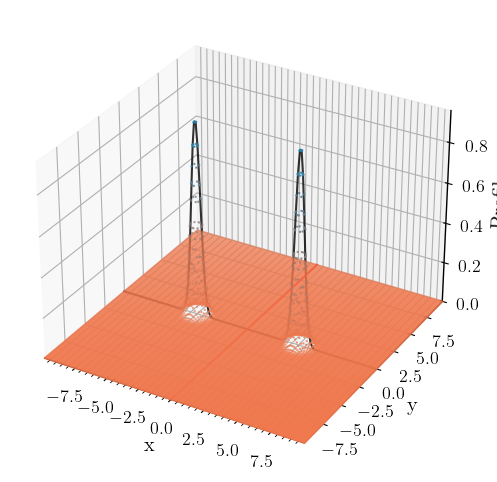

Showing the Z=0, X-Y plane


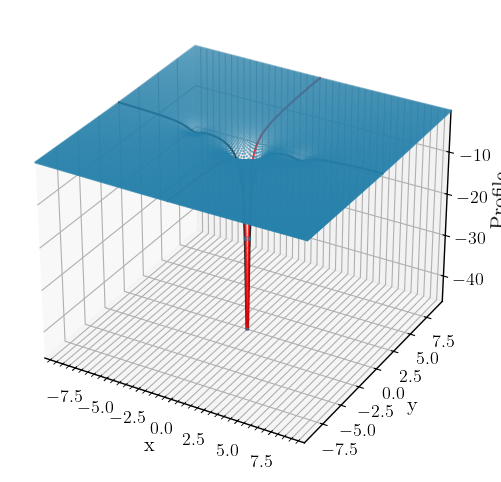

Progress: [####################] 100%
 All data was save


Complete. Total time ->  72.94590616226196
save_frames 11 



In [13]:
# Beginning the simulation
eu.evolve(model_parameters=parameters_gauss,
           field_components=compfield,
           salva_data_update=salva_data,
           simulation_parameters_update=simulation_parameters,
           comp_conserv_update=comp_conserv,
           info=False)

#### Simulation information

Using the file `parameters.txt` that appear inside of the simulation folder, we can load the simulation information

In [19]:
# Loading the n = 0 simulation data
address = "simulation_data/gaussiana_central_pot/"
name = "parameters.txt"
format =  eu.give_parameter(address + name, "format")
save_number =  eu.give_parameter(address + name, "save_number")
gridlength =  eu.give_parameter(address + name, "gridlength")
step_factor =  eu.give_parameter(address + name, "step_factor")
tmax =  eu.give_parameter(address + name, "tmax")

print(address, '\n', format, '\n', save_number)

simulation_data/gaussiana_central_pot/ 
 npz 
 10


Extracting the Simulation Data

In [31]:
filenames

['end_save_phi.npz',
 'end_save_rho.npz',
 'end_save_plane_phi.npz',
 'end_save_plane_rho.npz',
 'end_save_line_rho.npz',
 'end_grid.npz',
 'end_save_line_phi.npz']

In [32]:
filenames = eu.nameData(address, format, info=True)
print(filenames)

# extracting the grid coordinates
if 'end_grid.npz' in filenames:
    temp = np.load(address + f"/{'end_grid.npz'}")
    grid = [temp[cord] for cord in ['x', 'y', 'z']]
    print("save grid")

# extracting the x-proyections
names_lineal = {'end_save_line_psi.npz': None,
         'end_save_line_rho.npz': None,
         'end_save_line_phi.npz': None
}
for temp_name in names_lineal:
    if temp_name in filenames:
        temp = np.load(address + f"/{temp_name}")
        names_lineal[temp_name] = [temp['%s%s'%(temp_name[4:-4], num)] for num in range(0, save_number+1)]
        print("save x proyection ", temp_name)


# extracting the x, y -proyections
names_plane = {"end_save_plane_rho.npz": None,
               "end_save_plane_psi.npz": None,
               "end_save_plane_phi.npz": None
}
for temp_name in names_plane:
    if temp_name in filenames:
        temp = np.load(address + f"/{temp_name}")
        names_plane[temp_name] = [temp['%s%s'%(temp_name[4:-4], num)] for num in range(0, save_number+1)]
        print("save plane proyection ", temp_name)

# extracting the profiles
names_quant = {"end_save_rho.npz": None,
              "end_save_psi.npz": None,
              "end_save_phi.npz": None
}
for temp_name in names_quant:
    if temp_name in filenames:
        temp = np.load(address + f"/{temp_name}")
        names_quant[temp_name] = [temp['%s%s'%(temp_name[4:-4], num)] for num in range(0, save_number+1)]
        print("save profile ", temp_name)

Found 7 files with the .npz extension.
['end_save_phi.npz', 'end_save_rho.npz', 'end_save_plane_phi.npz', 'end_save_plane_rho.npz', 'end_save_line_rho.npz', 'end_grid.npz', 'end_save_line_phi.npz']
save grid
save x proyection  end_save_line_rho.npz
save x proyection  end_save_line_phi.npz
save plane proyection  end_save_plane_rho.npz
save plane proyection  end_save_plane_phi.npz
save profile  end_save_rho.npz
save profile  end_save_phi.npz


In [33]:
# Time of simulation, intervalor's time, etc.

ht, its_per_save, num_steps = eu.dtime(tmax, gridlength, resol, step_factor, save_number)

dt = its_per_save * ht
print("Time between saved iteration (n -> %d) "%its_per_save, dt)
print("Total time -> ", dt * save_number, " (equivalent to tmax) ", tmax)

Time between saved iteration (n -> 101)  0.5
Total time ->  5.0  (equivalent to tmax)  5.0


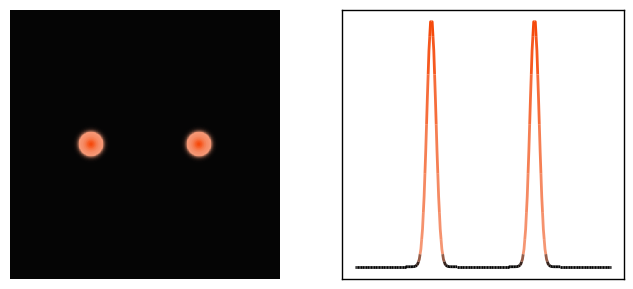

(<Figure size 800x350 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

In [34]:
## Illustrative plots from the previusly load data

frame = 0

data = names_plane["end_save_plane_rho.npz"][frame].T
da2 = [grid[0], names_lineal['end_save_line_rho.npz'][frame]]

cmapint = [(0, '#050505'), (0.05, '#f59876'),
           (0.5, '#f57d51'), (0.75, '#f76834'),
           (1, '#f54a0c')]

eu.imagshow2D(data, da2, save=False, xlim=(-1, 1), ylim=(-1, 1), cmapint=cmapint)

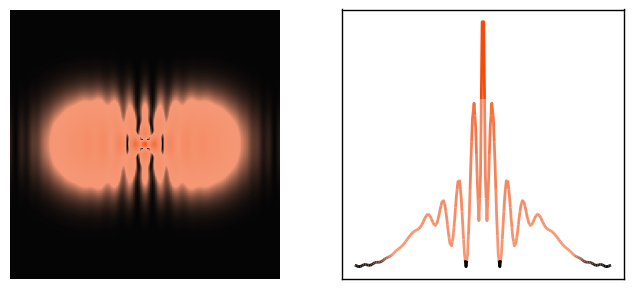

(<Figure size 800x350 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

In [35]:
## Illustrative plots from the previusly load data

frame = 3

data = names_plane["end_save_plane_rho.npz"][frame].T
da2 = [grid[0], names_lineal['end_save_line_rho.npz'][frame]]

cmapint = [(0, '#050505'), (0.05, '#f59876'),
           (0.5, '#f57d51'), (0.75, '#f76834'),
           (1, '#f54a0c')]

eu.imagshow2D(data, da2, save=False, xlim=(-1, 1), ylim=(-1, 1), cmapint=cmapint)

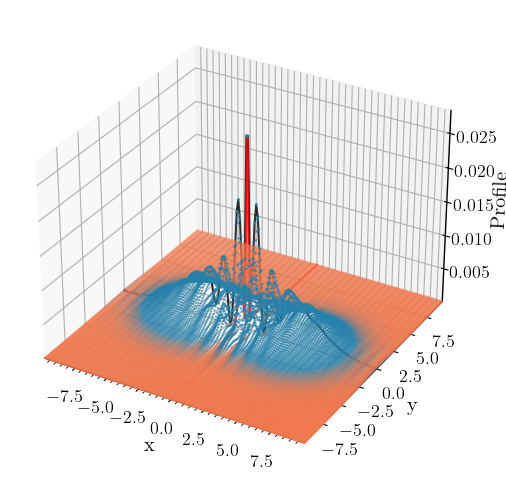

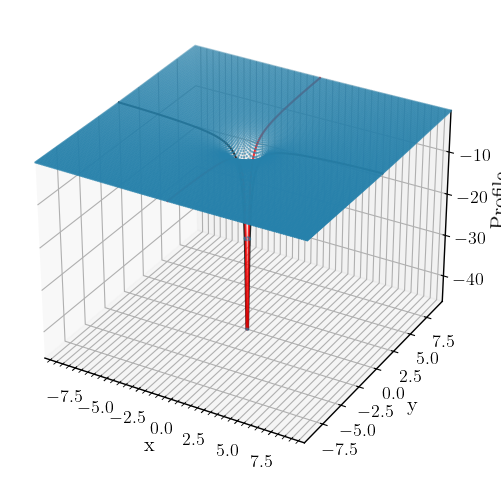

In [38]:
frame = 3
rho = names_plane["end_save_plane_rho.npz"][frame]
phisp = names_plane["end_save_plane_phi.npz"][frame] # names_quant["end_save_phi.npz"][frame]
xd, yd = grid[0], grid[1]
cxd, cyd = 'x', 'y'
resol = simulation_parameters['resol']

eu.PlaneProf(rho, xd, yd, cxd, cyd, save=False)  # density field
eu.PlaneProf(phisp, xd, yd, cxd, cyd, save=False)  # Potential field
# eu.PlaneProf(phisp[:, :, int(resol/2)], xd, yd, cxd, cyd, save=False)  # Potential field

#### Illustrative videos from the save data

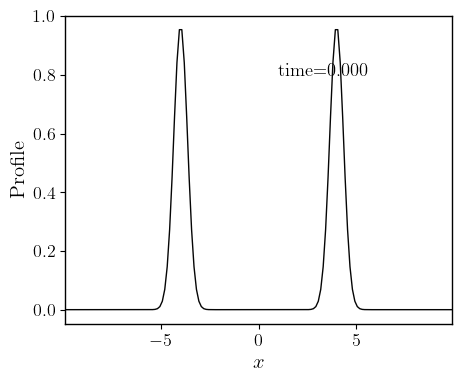

In [40]:
figData = plt.subplots(nrows=1, ncols=1, figsize=(5, 4), sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.13))

dvideo = eu.Visualization(address, figData)  # creando el objeto

n0 = 0  # begin frame
nameP = "save_line_rho" # "save_line_psi" # "save_line_rho"
struc = ['-', 1, ['#050505', '#f0784d',"#f00dca"]]
nameV = 'lin_dens'
coord = ['x']
plot2D = "field"  # "density"

video = dvideo.video(nameP, struc, nameV, coord=coord, 
                     xlim=None, ylim=None,
                     show=False, n0=n0, plot2D=plot2D, 
                     save=False,
                     dt=dt)
display(video)

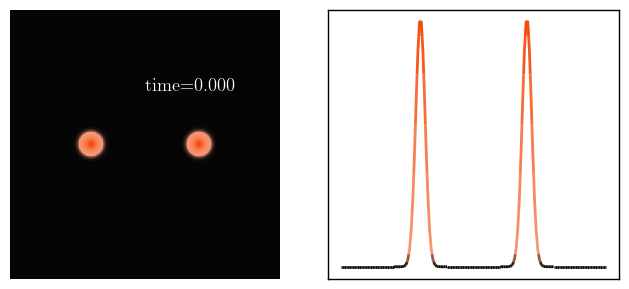

In [41]:
# Example of 2D video

figData = plt.subplots(nrows=1, ncols=2, figsize=(8, 3.5), sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.13))

dvideo = eu.Visualization(address, figData)  # making the object

n0 = 0  # begin frame
nameP = "save_line_rho"
name2 = "save_plane_rho"
struc = ['-', 2, '#f0784d']
nameV = 'proca_solit_0'
coord = ['x']
cmapint = [(0, '#050505'),
         (0.05, '#f59876'),
         (0.5, '#f57d51'),
         (0.75, '#f76834'),
          (1, '#f54a0c')]
vconf = [3, 1000000, ['-vcodec', 'libx264']]
plot2D = "density"  # "density"  "field"
text = r' '

video = dvideo.video(nameP, struc, nameV, name2=name2, cmapint=cmapint,
                     coord=coord, show=False, n0=n0, plot2D=plot2D,
                     vconf=vconf, save=False,  # change to false if you like to see in the notebook
                     xlim=(-1, 1), ylim=(-1, 1), text=text)
display(video)